## Import libs

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.python.data import Dataset
from tensorflow.keras.optimizers import Adam
import seaborn as sns


from falsb4mpa.modeling.zhang.learning.multi_adv import train_loop as zhang_train
from falsb4mpa.dataset.load_data import load_data
from falsb4mpa.evaluation.evaluation import compute_predictive_metrics, compute_fair_metrics, compute_adv_metrics, compute_tradeoff, fair_evaluation, compute_intersectional_fair_metrics
from falsb4mpa.modeling.zhang.models.multi_adv import ZhangMultAdv

## Preliminaries

In [2]:
batch_size = 64
epochs = 10
learning_rate = 0.001
opt = Adam(learning_rate=learning_rate)

In [3]:
cv_seeds = [13]
# cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'adult-mpa-bin-wout-agg'

In [5]:
x, y, a1, a2 = load_data(data_name)
raw_data = (x, y, a1, a2)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
a1dim = a1.shape[1]
a2dim = a2.shape[1]
zdim = 8
print(xdim, ydim, a1dim, a2dim, zdim)

97 1 1 1 8


## Result file

In [7]:
header = "model_name", "cv_seed", "clas_acc", "a1_dp", "a1_deqodds", "a1_deqopp", "a1_TN_g0", "a1_FP_g0", "a1_FN_g0", "a1_TP_g0", "a1_TN_g1", "a1_FP_g1", "a1_FN_g1", "a1_TP_g1", "a0_dp", "a0_deqodds", "a0_deqopp", "a0_TN_g0", "a0_FP_g0", "a0_FN_g0", "a0_TP_g0", "a0_TN_g1", "a0_FP_g1", "a0_FN_g1", "a0_TP_g1"

results = []

## Testing

In [8]:
fairdef = "EqOdds"

for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
        x, y, a1, a2, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    opt = Adam(learning_rate=learning_rate)

    model = ZhangMultAdv(xdim=xdim, ydim=ydim, a1dim=a1dim, a2dim=a2dim, batch_size=batch_size, fairdef=fairdef)
    
    ret = zhang_train(model, raw_data, train_data, epochs, opt)

    Y, A1, A2, Y_hat, A1_hat, A2_hat = fair_evaluation(model, test_data)
    
    clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(Y, Y_hat)
    
    adv1_acc = compute_adv_metrics(A1, A1_hat)
    adv2_acc = compute_adv_metrics(A2, A2_hat)
    
    a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(Y, A1, Y_hat, a1dim)
    a2_dp, a2_deqodds, a2_deqopp, a2_metrics_g0, a2_metrics_g1 = compute_fair_metrics(Y, A2, Y_hat, a2dim)

    wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(Y, A1, A2, Y_hat, a1dim, a2dim)


    # fair_metrics = (dp, deqodds, deqopp)
    # tradeoff = []
    # for fair_metric in fair_metrics:
    #     tradeoff.append(compute_tradeoff(clas_acc, fair_metric))

    # result = ['Zhang4EqOdds', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    result = ['Zhang4EqOdds', cv_seed, clas_acc, a1_dp, a1_deqodds, a1_deqopp] + a1_metrics_g0 + a1_metrics_g1 
    result += [a2_dp, a2_deqodds, a2_deqopp] + a2_metrics_g0 + a2_metrics_g1
    result += [wc_spd, wc_aod, wc_eod]


    results.append(result)

    del(opt)

/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:731: UserWarning: Gradients do not exist for variables ['U:0', 'c:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
2026-05-04 14:29:21.131933: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 1 | Clf loss/acc 0.38/0.72 | Adv1 loss/acc 0.71/0.67 | Adv2 loss/acc 0.53/0.86


2026-05-04 14:29:37.596814: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 2 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.79/0.67 | Adv2 loss/acc 0.55/0.86
> Epoch: 3 | Clf loss/acc 0.34/0.83 | Adv1 loss/acc 0.87/0.67 | Adv2 loss/acc 0.57/0.86


2026-05-04 14:30:10.409655: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 4 | Clf loss/acc 0.34/0.83 | Adv1 loss/acc 0.94/0.67 | Adv2 loss/acc 0.59/0.86
> Epoch: 5 | Clf loss/acc 0.34/0.83 | Adv1 loss/acc 1.00/0.67 | Adv2 loss/acc 0.62/0.86
> Epoch: 6 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 1.06/0.67 | Adv2 loss/acc 0.65/0.86
> Epoch: 7 | Clf loss/acc 0.36/0.83 | Adv1 loss/acc 1.13/0.67 | Adv2 loss/acc 0.68/0.86


2026-05-04 14:31:16.709172: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 8 | Clf loss/acc 0.37/0.83 | Adv1 loss/acc 1.20/0.67 | Adv2 loss/acc 0.71/0.86
> Epoch: 9 | Clf loss/acc 0.37/0.83 | Adv1 loss/acc 1.28/0.67 | Adv2 loss/acc 0.74/0.86
> Epoch: 10 | Clf loss/acc 0.38/0.83 | Adv1 loss/acc 1.36/0.67 | Adv2 loss/acc 0.77/0.86
> Predictive Performance Evaluation
> Class Acc = 0.8333086371421814
> Confusion Matrix 
TN: 9172.0 | FP: 986.0 
FN: 1265.0 | TP: 2081.0
> Adv Acc = 0.6753554344177246
> Adv Acc = 0.8581901788711548
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8246995210647583 | 0.9406177997589111 | 0.9657945036888123
> Confusion Matrix for A = 0 
TN: 5476.0 | FP: 813.0 
FN: 1057.0 | TP: 1778.0
> Confusion Matrix for A = 1 
TN: 3696.0 | FP: 173.0 
FN: 208.0 | TP: 303.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.9099867939949036 | 0.9747509956359863 | 0.9897181391716003
> Confusion Matrix for A = 0 
TN: 7661.0 | FP: 884.0 
FN: 1148.0 | TP: 1896.0
> Confusion Matrix for A = 1 
TN: 1511.0 | FP: 102.0 
FN: 117.0 | TP: 185.0
> Intersec

In [9]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.83330864 0.8333086492890995 0.7698479285388796


<Axes: >

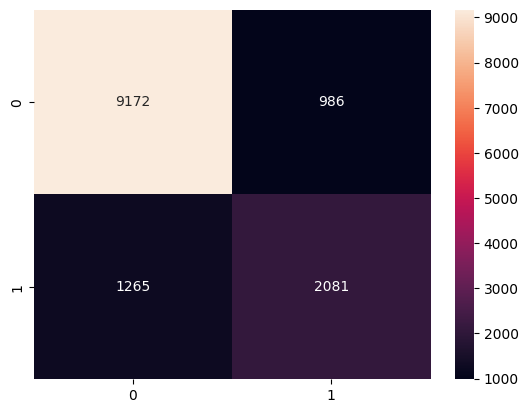

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [11]:
# result_df = pd.DataFrame(results, columns=header)
# result_df

In [12]:
# result_df.to_csv(f'{data_name}-result/unfair_lr-{epochs}.csv')